In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.multioutput import MultiOutputRegressor

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

In [2]:
file_path = r"C:\Users\singh\Downloads\561 file for ML Model.xlsx"

df = pd.read_excel(file_path)

print("\n========== DATASET INFORMATION ==========")
print("Dataset Shape :", df.shape)

print("\nColumns:")
print(df.columns.tolist())


========== DATASET INFORMATION ==========
Dataset Shape : (560, 30)

Columns:
['C', 'Mn', 'Si', 'Al', 'B', 'N', 'Ca', 'P', 'Ni', 'S', 'Cr', 'Mo', 'Ti', 'V', 'Nb', 'Ni.1', 'Zn', 'Cu', 'Sn', 'W', 'Co', 'Zr', 'O', 'Mg', 'Ti*', 'UTS (MPa)', 'YS (MPa)', 'Total Elongation (%)', 'Engg. Strain', 'n-Value']


In [3]:
X = df.drop(columns=[
    "Total Elongation (%)",
    "Engg. Strain",
    "n-Value"
])

y = df[[
    "UTS (MPa)",
    "YS (MPa)",
]]


print("\nInput Shape :", X.shape)
print("Output Shape:", y.shape)


Input Shape : (560, 27)
Output Shape: (560, 2)


In [4]:
print("\n========== MISSING VALUES ==========")

print(
    "Input Missing Values :",
    X.isnull().sum().sum()
)

print(
    "Output Missing Values :",
    y.isnull().sum().sum()
)


========== MISSING VALUES ==========
Input Missing Values : 0
Output Missing Values : 0


In [5]:
X_train, X_validation, y_train, y_validation = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


print("\n========== DATA SPLIT ==========")

print(
    "Training Samples :",
    X_train.shape[0]
)

print(
    "Validation Samples :",
    X_validation.shape[0]
)



========== DATA SPLIT ==========
Training Samples : 448
Validation Samples : 112


In [6]:
X_scaler = StandardScaler()

y_scaler = StandardScaler()


X_train_scaled = X_scaler.fit_transform(
    X_train
)


X_validation_scaled = X_scaler.transform(
    X_validation
)


y_train_scaled = y_scaler.fit_transform(
    y_train
)


In [ ]:
svr_model = SVR(
    kernel="rbf",
    C=100,
    epsilon=0.1,
    gamma="scale"
)



model = MultiOutputRegressor(
    svr_model
)
print("\n========== TRAINING SVR MODEL ==========")

model.fit(
    X_train_scaled,
    y_train_scaled
)

print("SVR Model Training Completed")


========== TRAINING SVR MODEL ==========
SVR Model Training Completed


In [8]:

y_pred_scaled = model.predict(
    X_validation_scaled
)


y_pred = y_scaler.inverse_transform(
    y_pred_scaled
)

In [9]:

mse = mean_squared_error(
    y_validation,
    y_pred
)


rmse = np.sqrt(
    mse
)


mae = mean_absolute_error(
    y_validation,
    y_pred
)


r2 = r2_score(
    y_validation,
    y_pred
)


print(
    "\n========== SVR MODEL RESULT =========="
)


print(
    "MSE      :",
    mse
)


print(
    "RMSE     :",
    rmse
)


print(
    "MAE      :",
    mae
)


print(
    "R2 Score :",
    r2
)



========== SVR MODEL RESULT ==========
MSE      : 3384.627361652384
RMSE     : 58.17755032357743
MAE      : 28.560212210241975
R2 Score : 0.9213615418501976


In [10]:
print(
    "\n========== SUPPORT VECTOR INFORMATION =========="
)


for i, estimator in enumerate(
    model.estimators_
):

    support_vector_count = len(
        estimator.support_
    )


target_columns = [
    "UTS (MPa)",
    "YS (MPa)"
]


========== SUPPORT VECTOR INFORMATION ==========


In [11]:
train_pred_scaled = model.predict(X_train_scaled)

train_pred = y_scaler.inverse_transform(train_pred_scaled)

train_r2 = r2_score(
    y_train,
    train_pred
)

print("Train R2 :", train_r2)

Train R2 : 0.9946622862990818


In [12]:
print("\nIndividual R2")

for i,col in enumerate(y.columns):

    score = r2_score(
        y_validation.iloc[:,i],
        y_pred[:,i]
    )

    print(col,":",score)


Individual R2
UTS (MPa) : 0.9228715485881167
YS (MPa) : 0.9198515351122785


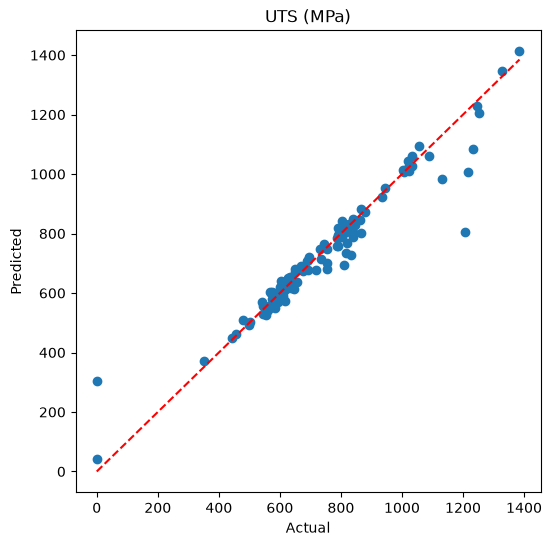

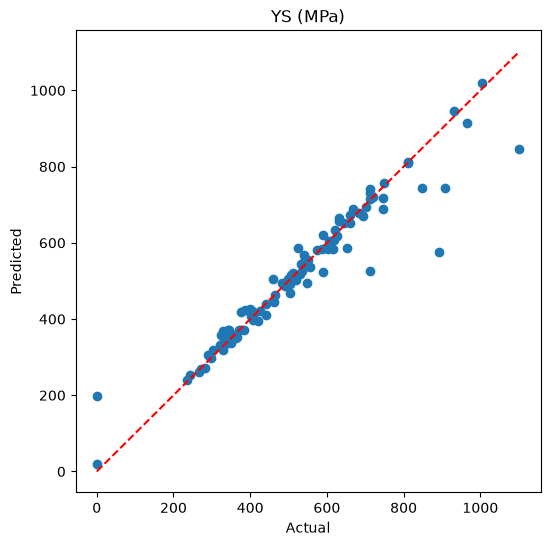

In [13]:
import matplotlib.pyplot as plt

for i,col in enumerate(y.columns):

    plt.figure(figsize=(6,6))

    plt.scatter(
        y_validation.iloc[:,i],
        y_pred[:,i]
    )

    plt.plot(
        [y_validation.iloc[:,i].min(),
         y_validation.iloc[:,i].max()],
        [y_validation.iloc[:,i].min(),
         y_validation.iloc[:,i].max()],
        'r--'
    )

    plt.xlabel("Actual")

    plt.ylabel("Predicted")

    plt.title(col)

    plt.show()

In [14]:
prediction_df = pd.DataFrame()


for i, column in enumerate(target_columns):

    prediction_df[
        "Actual_" + column
    ] = y_validation.iloc[:, i].values


    prediction_df[
        "Predicted_" + column
    ] = y_pred[:, i]

In [15]:

print(
    "\n========== PREDICTION RESULT =========="
)


print(
    prediction_df.head(10)
)



========== PREDICTION RESULT ==========
   Actual_UTS (MPa)  Predicted_UTS (MPa)  Actual_YS (MPa)  Predicted_YS (MPa)
0               351           370.616048              235          239.545654
1               591           581.715222              296          299.437981
2               820           826.925847              540          540.385962
3               820           767.031454              615          583.197805
4               498           492.724798              271          269.467186
5               817           811.643613              712          731.380245
6               788           756.662163              597          586.989785
7              1019          1019.765586              645          651.257633
8              1020          1042.430619              720          720.145623
9               745           765.848666              342          370.258833


In [16]:
print(
    "\n========== INDIVIDUAL MSE SCORE =========="
)


y_validation_array = y_validation.to_numpy()


for i, column in enumerate(target_columns):

    score = mean_squared_error(
        y_validation_array[:, i],
        y_pred[:, i]
    )


    print(
        column,
        ":",
        score
    )


========== INDIVIDUAL MSE SCORE ==========
UTS (MPa) : 3854.185845503222
YS (MPa) : 2915.0688778015465


In [17]:
print(
    "\n========== INDIVIDUAL MAE SCORE =========="
)


y_validation_array = y_validation.to_numpy()


for i, column in enumerate(target_columns):

    score = mean_absolute_error(
        y_validation_array[:, i],
        y_pred[:, i]
    )


    print(
        column,
        ":",
        score
    )


========== INDIVIDUAL MAE SCORE ==========
UTS (MPa) : 31.53472975372321
YS (MPa) : 25.58569466676074


In [18]:
import sklearn.metrics as root_mean_squared_error
print(
    "\n========== INDIVIDUAL RMSE SCORE =========="
)


y_validation_array = y_validation.to_numpy()


for i, column in enumerate(target_columns):

    mse = mean_squared_error(y_validation_array[:, i], y_pred[:, i])
    rmse = np.sqrt(mse)

    print(column, ":", rmse)


========== INDIVIDUAL RMSE SCORE ==========
UTS (MPa) : 62.082089571012524
YS (MPa) : 53.9913778098091


In [19]:

print(
    "\n========== INDIVIDUAL R2 SCORE =========="
)


y_validation_array = y_validation.to_numpy()


for i, column in enumerate(target_columns):

    score = r2_score(
        y_validation_array[:, i],
        y_pred[:, i]
    )


    print(
        column,
        ":",
        score
    )


========== INDIVIDUAL R2 SCORE ==========
UTS (MPa) : 0.9228715485881167
YS (MPa) : 0.9198515351122785


In [20]:
prediction_df.to_excel(
    "SVR_Prediction_Result.xlsx",
    index=False
)


print(
    "\nSVR Prediction Result Saved Successfully"
)


SVR Prediction Result Saved Successfully


In [21]:
print(df.dtypes)

C                       float64
Mn                      float64
Si                      float64
Al                      float64
B                       float64
N                       float64
Ca                      float64
P                       float64
Ni                      float64
S                       float64
Cr                      float64
Mo                      float64
Ti                      float64
V                       float64
Nb                      float64
Ni.1                    float64
Zn                      float64
Cu                      float64
Sn                      float64
W                       float64
Co                      float64
Zr                      float64
O                       float64
Mg                      float64
Ti*                     float64
UTS (MPa)                 int64
YS (MPa)                  int64
Total Elongation (%)    float64
Engg. Strain            float64
n-Value                 float64
dtype: object


In [22]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# ============================================================
# TRAIN PREDICTION
# ============================================================

y_train_pred_scaled = model.predict(X_train_scaled)
y_train_pred = y_scaler.inverse_transform(y_train_pred_scaled)

# ============================================================
# TEST PREDICTION
# ============================================================

y_test_pred_scaled = model.predict(X_validation_scaled)
y_test_pred = y_scaler.inverse_transform(y_test_pred_scaled)

# ============================================================
# OVERALL TRAIN METRICS
# ============================================================

train_r2 = r2_score(y_train, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))

# ============================================================
# OVERALL TEST METRICS
# ============================================================

test_r2 = r2_score(y_validation, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_validation, y_test_pred))

print("\n========== OVERALL RESULT ==========")
print(f"Train R2   : {train_r2:.4f}")
print(f"Train RMSE : {train_rmse:.4f}")
print()
print(f"Test R2    : {test_r2:.4f}")
print(f"Test RMSE  : {test_rmse:.4f}")


========== OVERALL RESULT ==========
Train R2   : 0.9947
Train RMSE : 14.7707

Test R2    : 0.9214
Test RMSE  : 58.1776
